<a href="https://colab.research.google.com/github/gilIolgenblum/CrowdingModeWorkshop/blob/main/tutorials/06_statistical_analysis_and_uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical Analysis and Uncertainty Estimation
In experimental biophysics, providing a single fitted value for parameters like $\varepsilon$ or $\varepsilon_{TS}$ is rarely enough; we need to estimate their uncertainties. 

Because the Flory-Huggins crowding equations are non-linear, standard error propagation can be complex. Instead, we can use **Monte Carlo Subsampling** (also called repeated random sub-sampling validation or Monte Carlo cross-validation).

This tutorial demonstrates how to use the `monte_carlo_subsampling` tool on a real dataset: the folding stability of **MET16** in the presence of **trehalose**. Data is taken from *Olgenblum, Carmon, & Harries (2023)*.


In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/CrowdingModeWorkshop.git
    # Change the working directory to the repository root
    os.chdir('/content/CrowdingModeWorkshop')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/CrowdingModeWorkshop/src')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import crowding as cr
import warnings
warnings.filterwarnings('ignore')

# 1. Initialize Protein and Cosolute
met16 = cr.Protein(SASA=419.0) # Approximate N and SASA
trehalose = cr.Cosolute(nu=11.7, chi=0.433, chiTS=-1.12) # MW of trehalose / 18

# 2. Initialize the binary model
model = cr.CrowdingModel(protein=met16, cosolute=trehalose, dphiC=0.0001, phiC_max=0.22)

# 3. Load the data
df = pd.read_csv('../app/sample_data/met16_trehalose_binary_format1.csv')
exp_conc = df['concentration'].values
exp_ddG = df['dG'].values
exp_ddH = df['dH'].values
exp_TddS = df['TdS'].values

df.head()


,concentration,dG,dH,TdS
0,0.16483,-0.213410,-1.722151,-1.286528
1,0.29679,-0.524680,-1.832636,-1.193054
2,0.34045,-0.502030,-1.755585,-1.355657
3,0.40000,-0.587706,-1.833360,-1.278550
4,0.51656,-0.897850,-2.416299,-1.741963


## Baseline Fit
Before performing statistical analysis, let's look at the standard fit using the entire dataset. We will fit both $\varepsilon$ and $\varepsilon_{TS}$ to the enthalpy ($\Delta\Delta H^0$) and entropy ($T\Delta\Delta S^0$) profiles.

We will use `fit_eps` and `fit_epsTS` to fit the soft interaction parameters.


In [3]:
model.fit_eps(exp_conc, exp_ddG, concentration_type='molal', progress_bar=True, disp=False)
model.fit_epsTS(exp_conc, exp_ddH, exp_TddS, concentration_type='molal', progress_bar=True, disp=False)

print(f"Fitted eps: {model.eps:.4f} kJ/mol")
print(f"Fitted eps_TS: {model.epsTS:.4f} kJ/mol")
print(f"Fitted eps_H: {model.epsH:.4f} kJ/mol")


Fitting eps: 0iter [00:00, ?iter/s]

Fitting epsTS: 0iter [00:00, ?iter/s]

Fitted eps: 0.0141 kJ/mol
Fitted eps_TS: 0.3155 kJ/mol
Fitted eps_H: 0.3296 kJ/mol


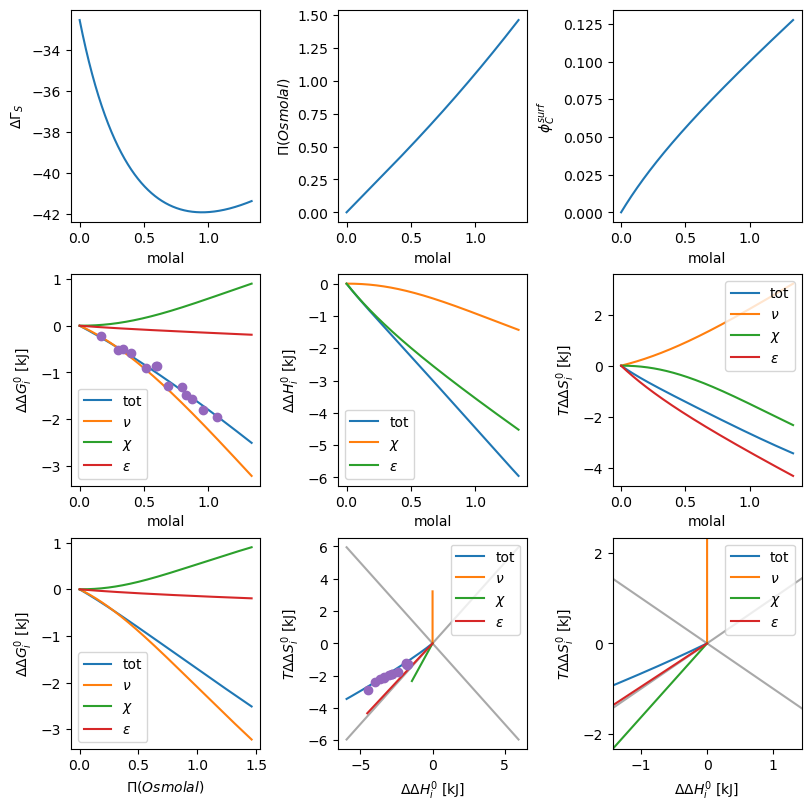

In [4]:
plotter = cr.Plotter(model)
fig = plotter.plot_results(
    concentration_type='molal',
    exp_conc=exp_conc,
    exp_ddG=exp_ddG,
    exp_ddH=exp_ddH,
    exp_TddS=exp_TddS
)
plt.show()

## Monte Carlo Subsampling
The `monte_carlo_subsampling` function is extremely flexible. It works by randomly choosing a subset of your data points (e.g. 80%) repeatedly for `N` iterations. 

To use it, you just define a custom Python function (a closure) that takes a list of randomized indices (`idx`), slices your data, runs the fit, and returns the parameters you want to track as a dictionary.


In [5]:
def fit_and_extract_eps(idx):
    # mode = 'G' or 'TS'

    # 1. Slice the experimental arrays using the randomized indices
    sub_conc = exp_conc[idx]
    sub_ddG = exp_ddG[idx]
    
    # 2. Run the fit silently
    model.fit_eps(sub_conc, sub_ddG, concentration_type='molal', disp=False, progress_bar=False, auto_solve=False)
    return {'eps': model.eps}
  
def fit_and_extract_epsTS(idx):
    # mode = 'G' or 'TS'

    # 1. Slice the experimental arrays using the randomized indices
    sub_conc = exp_conc[idx]
    sub_ddH = exp_ddH[idx]
    sub_TddS = exp_TddS[idx]
    
    # 2. Run the fit silently
    model.fit_epsTS(sub_conc, sub_ddH, sub_TddS, concentration_type='molal', disp=False, progress_bar=False, auto_solve=False)
    return {'epsTS': model.epsTS, 'epsH': model.epsH}


Now we pass this function to the subsampler. We will run it 100 times, retaining 80% of the data points each time.


In [6]:
# This will take a few seconds
df_results_esp = cr.monte_carlo_subsampling(
    n_points=len(exp_conc),
    fit_and_extract=fit_and_extract_eps,
    n_iterations=100,
    subsample_fraction=0.8,
    progress_bar=True
)

df_results_espTS = cr.monte_carlo_subsampling(
    n_points=len(exp_conc),
    fit_and_extract=fit_and_extract_epsTS,
    n_iterations=100,
    subsample_fraction=0.8,
    progress_bar=True
)

df_results = pd.concat([df_results_esp,df_results_espTS], axis=1)
df_results.head()


Monte Carlo Subsampling:   0%|          | 0/100 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/100 [00:00<?, ?it/s]

,eps,epsTS,epsH
0,0.010642,0.311065,0.323514
1,0.012277,0.312468,0.324917
2,0.014265,0.313257,0.325706
3,0.015670,0.315837,0.328286
4,0.013817,0.313585,0.326034


## Analyzing Uncertainties
With the distribution of fitted parameters, we can calculate the mean and standard deviation, which gives us a robust estimate of the uncertainty!


,mean,std,RSD (%)
eps,0.013839,0.001616,11.675182
epsTS,0.315273,0.004036,1.280041
epsH,0.327723,0.004036,1.231416


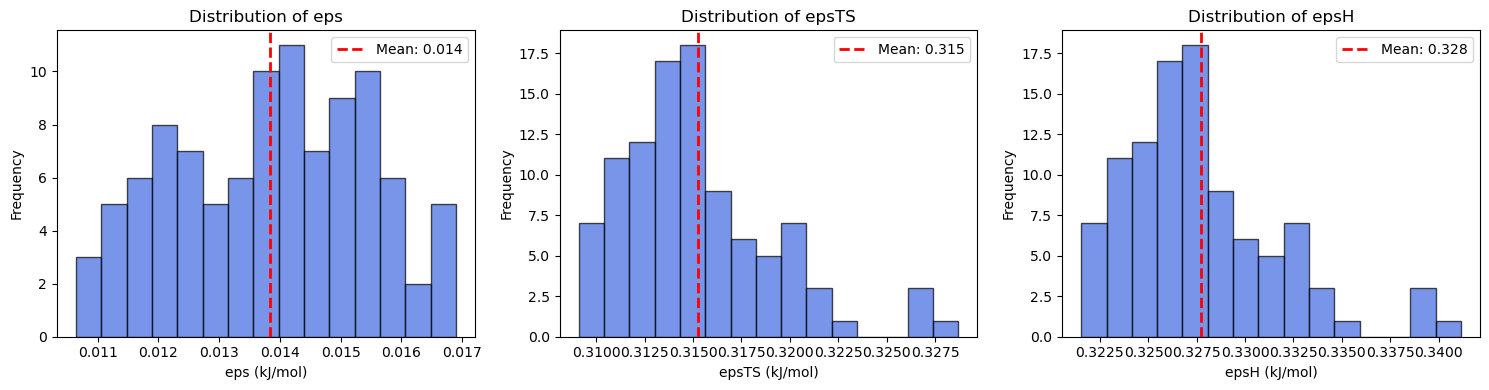

In [7]:
# Calculate statistics
stats = df_results.agg(['mean', 'std']).T
stats['RSD (%)'] = (stats['std'] / np.abs(stats['mean'])) * 100 # Relative Standard Deviation
display(stats)

# Plot Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['eps', 'epsTS', 'epsH']):
    ax = axes[i]
    ax.hist(df_results[col], bins=15, color='royalblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(f'{col} (kJ/mol)')
    ax.set_ylabel('Frequency')
    
    # Add vertical line for the mean
    mean_val = stats.loc[col, 'mean']
    ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.3f}')
    ax.legend()

plt.tight_layout()
plt.show()
